# Hyperparameter Tuning in Neural Networks

### Objective
This notebook aims to explore and compare two common hyperparameter tuning methods, **Grid Search** and **Random Search**, on a Multi-Layer Perceptron (MLP) classifier. We will:
1.  Establish a **baseline performance** with a simple model.
2.  Apply **Grid Search** and **Random Search** to find optimal hyperparameters.
3.  **Compare** the methods based on performance and computational cost.
4.  Prepare a summary **report** of the findings.

**Dataset:** Breast Cancer Wisconsin Dataset

In [73]:
# --- Core Libraries for Data Handling and Machine Learning ---
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# --- Scikit-learn Utilities ---
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# --- SciKeras Wrapper for Keras and Scikit-learn Integration ---
from scikeras.wrappers import KerasClassifier

# --- Plotting Libraries for Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plot style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [74]:
# Load the dataset from scikit-learn's built-in datasets
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (569, 30)
Target (y) shape: (569,)


## 1. Exploratory Data Analysis (EDA)
Before modeling, we must understand our data. We will check its structure, look for missing values, and analyze the distribution of its features and target variable.

In [75]:
# Convert to a Pandas DataFrame for easier analysis
df = pd.DataFrame(X, columns=cancer.feature_names)
df['target'] = y

# Display the first 5 rows to get a feel for the data
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [76]:
# Get descriptive statistics. Notice the huge differences in the 'mean', 'std', and 'max' columns.
# This confirms that feature scaling is absolutely necessary.
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


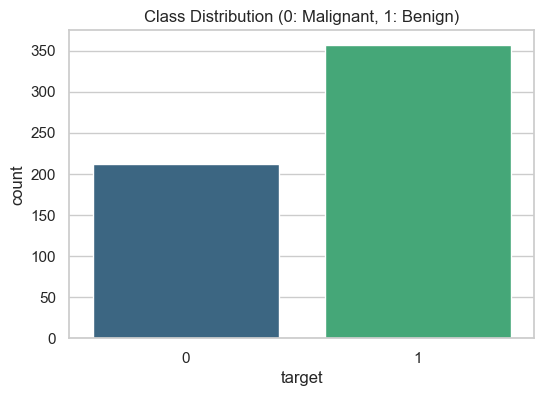

Target class counts:
target
1    357
0    212
Name: count, dtype: int64

The dataset is reasonably balanced, which is good for training.


In [77]:
# Visualize the distribution of the target classes
plt.figure(figsize=(6, 4))
sns.countplot(x='target', hue='target', data=df, palette='viridis', legend=False)
plt.title('Class Distribution (0: Malignant, 1: Benign)')
plt.show()

# Print the exact counts
print("Target class counts:")
print(df['target'].value_counts())
print("\nThe dataset is reasonably balanced, which is good for training.")

## 2. Data Preprocessing
As seen in the EDA, features have vastly different scales. We will now:
1.  Split the data into training and testing sets.
2.  Apply `StandardScaler` to scale our features.

In [78]:
# 1. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the features
# We fit the scaler ONLY on the training data to prevent data leakage from the test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of scaled training data: {X_train_scaled.shape}")
print(f"Shape of scaled testing data: {X_test_scaled.shape}")

Shape of scaled training data: (455, 30)
Shape of scaled testing data: (114, 30)


## 3. Modeling
We will now build and tune our neural network.

In [79]:
print("--- Building and Evaluating Baseline Model ---")

# Define a simple MLP architecture according to the assignment requirements
baseline_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)), # Input layer
    keras.layers.Dense(64, activation='relu'),            # A single hidden layer with 64 neurons
    keras.layers.Dense(1, activation='sigmoid')           # Output layer for binary classification
])

# Compile the model
baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (verbose=0 suppresses the epoch-by-epoch output for a cleaner notebook)
# We use a validation_split to monitor for overfitting during training.
baseline_model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2, verbose=0)

# Evaluate the baseline model on the unseen test data to get its true performance
loss, baseline_accuracy = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)

# This is the line that prints the value you need for your report
print(f"\nBaseline Model Test Accuracy: {baseline_accuracy:.4f}")

# Initialize a dictionary to store all our results for final comparison.
results = {}
# This 'results' dictionary will be used by all subsequent steps.
results = {
    'Baseline': {'accuracy': baseline_accuracy, 'time': 0} # Time is 0 for baseline as there is no "tuning"
}

--- Building and Evaluating Baseline Model ---

Baseline Model Test Accuracy: 0.9737


In [80]:
# Now display the model summary
baseline_model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,149 (24.02 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,100 (16.02 KB)

### Task 2: Tuning with Grid Search
Grid Search exhaustively tries every combination of the hyperparameters provided.


In [93]:
print("\n--- Performing Grid Search ---")

# Wrap in KerasClassifier for scikit-learn
keras_clf = KerasClassifier(model=create_model, epochs=20, verbose=0)

# Define the hyperparameter grid
param_grid = {
    'batch_size': [32, 64],
    'model__neurons': [32, 64, 128],
    'model__learning_rate': [0.001, 0.01]
}

# Create the GridSearchCV object
clf = GridSearchCV(estimator=keras_clf, param_grid=param_grid, cv=5, n_jobs=-1)

# Time it
start_time = time.time()
clf.fit(X_train_scaled, y_train)
grid_search_time = time.time() - start_time

# Display results as a DataFrame
grid_df = pd.DataFrame(clf.cv_results_)
grid_df



--- Performing Grid Search ---


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_batch_size,param_model__learning_rate,param_model__neurons,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.508556,0.128070,0.208878,0.021310,32,0.001,32,"{'batch_size': 32, 'model__learning_rate': 0.0...",0.978022,0.978022,0.967033,0.978022,0.956044,0.971429,0.008791,6
1,3.314362,0.369470,0.199276,0.030472,32,0.001,64,"{'batch_size': 32, 'model__learning_rate': 0.0...",0.989011,0.989011,0.967033,0.967033,0.978022,0.978022,0.009829,2
2,3.309175,0.179286,0.172367,0.009529,32,0.001,128,"{'batch_size': 32, 'model__learning_rate': 0.0...",0.989011,0.967033,0.978022,0.978022,0.989011,0.980220,0.008223,1
3,3.241866,0.188583,0.216162,0.038536,32,0.010,32,"{'batch_size': 32, 'model__learning_rate': 0.0...",0.967033,0.978022,0.967033,0.989011,0.956044,0.971429,0.011207,6
4,3.257453,0.139805,0.215612,0.029674,32,0.010,64,"{'batch_size': 32, 'model__learning_rate': 0.0...",0.967033,0.978022,0.967033,0.989011,0.934066,0.967033,0.018388,9
5,3.309408,0.148337,0.184740,0.009324,32,0.010,128,"{'batch_size': 32, 'model__learning_rate': 0.0...",0.967033,0.967033,0.967033,0.978022,0.956044,0.967033,0.006950,9
6,3.336478,0.175969,0.204223,0.029525,64,0.001,32,"{'batch_size': 64, 'model__learning_rate': 0.0...",0.934066,0.967033,0.978022,0.945055,0.945055,0.953846,0.016150,12
7,3.391365,0.193863,0.216209,0.033499,64,0.001,64,"{'batch_size': 64, 'model__learning_rate': 0.0...",0.967033,0.967033,0.967033,0.956044,0.967033,0.964835,0.004396,11
8,3.316175,0.113444,0.193732,0.015064,64,0.001,128,"{'batch_size': 64, 'model__learning_rate': 0.0...",0.989011,0.956044,0.978022,0.967033,0.967033,0.971429,0.011207,4
9,3.564988,0.312811,0.233914,0.024581,64,0.010,32,"{'batch_size': 64, 'model__learning_rate': 0.0...",1.000000,0.967033,0.956044,0.967033,0.967033,0.971429,0.014906,4


In [94]:
grid_df[['param_batch_size', 'param_model__neurons', 'param_model__learning_rate', 'mean_test_score']]

,param_batch_size,param_model__neurons,param_model__learning_rate,mean_test_score
0,32,32,0.001,0.971429
1,32,64,0.001,0.978022
2,32,128,0.001,0.980220
3,32,32,0.010,0.971429
4,32,64,0.010,0.967033
5,32,128,0.010,0.967033
6,64,32,0.001,0.953846
7,64,64,0.001,0.964835
8,64,128,0.001,0.971429
9,64,32,0.010,0.971429


In [95]:
# Best parameters and score
print(f"\nBest Parameters: {clf.best_params_}")
print(f"Best Accuracy: {clf.best_score_:.4f}")
print(f"Grid Search Time: {grid_search_time:.2f} seconds")
results['Grid Search'] = {
'accuracy': clf.best_score_,
'time': grid_search_time
}


Best Parameters: {'batch_size': 32, 'model__learning_rate': 0.001, 'model__neurons': 128}
Best Accuracy: 0.9802
Grid Search Time: 37.73 seconds


### Task 3: Tuning with Random Search
Random Search samples a fixed number of random combinations from a wider distribution of values, making it more efficient.


In [96]:
print("\n--- Performing Random Search ---")

from scipy.stats import randint, loguniform

# Define the parameter space
param_dist = {
    'batch_size': [16, 32, 64, 128],
    'model__neurons': randint(16, 257),  # continuous int sampling
    'model__learning_rate': loguniform(1e-4, 1e-1)  # continuous log-uniform sampling
}

# Create the RandomizedSearchCV object
# Using random_state=42 makes the "random" search reproducible
clf_random = RandomizedSearchCV(estimator=keras_clf, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42)

# Time it
start_time = time.time()
clf_random.fit(X_train_scaled, y_train)
random_search_time = time.time() - start_time

# Display results as a DataFrame
random_df = pd.DataFrame(clf_random.cv_results_)
print("\nRandom Search Results (condensed view):")
print(random_df[['param_batch_size', 'param_model__neurons', 'param_model__learning_rate', 'mean_test_score']].round(4))



--- Performing Random Search ---

Random Search Results (condensed view):
   param_batch_size  param_model__neurons  param_model__learning_rate  \
0                64                    30                      0.0245   
1                64                    36                      0.0218   
2                64                   230                      0.0022   
3                64                   132                      0.0024   
4               128                   146                      0.0003   
5                32                   103                      0.0001   
6               128                   145                      0.0654   
7               128                   176                      0.0948   
8               128                   251                      0.0068   
9                16                    74                      0.0007   

   mean_test_score  
0           0.9648  
1           0.9714  
2           0.9736  
3           0.9758  
4           0.92

In [97]:
# Best parameters and score
print(f"\nBest Parameters: {clf_random.best_params_}")
print(f"Best Accuracy: {clf_random.best_score_:.4f}")
print(f"Random Search Time: {random_search_time:.2f} seconds")

# Store results for final comparison
results['Random Search'] = {
    'accuracy': clf_random.best_score_,
    'time': random_search_time
}


Best Parameters: {'batch_size': 64, 'model__learning_rate': np.float64(0.002386418878005608), 'model__neurons': 132}
Best Accuracy: 0.9758
Random Search Time: 28.77 seconds


## 4. Comparison and Conclusion
Now we will consolidate our results into a table and visualize the outcome to draw final conclusions.

In [98]:
# First print the raw results dictionary
print("--- Raw Results Dictionary ---")
print(results)

# Then convert to DataFrame for a clean summary
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df['accuracy'] = results_df['accuracy'].round(4)
results_df['time'] = results_df['time'].round(2)
results_df = results_df.rename(columns={'accuracy': 'Best Accuracy', 'time': 'Tuning Time (s)'})

print("\n--- Summary of Results (Formatted DataFrame) ---")
print(results_df)

--- Raw Results Dictionary ---
{'Baseline': {'accuracy': 0.9736841917037964, 'time': 0}, 'Grid Search': {'accuracy': np.float64(0.9802197802197803), 'time': 37.734466552734375}, 'Random Search': {'accuracy': np.float64(0.9758241758241759), 'time': 28.769858837127686}}

--- Summary of Results (Formatted DataFrame) ---
               Best Accuracy  Tuning Time (s)
Baseline              0.9737             0.00
Grid Search           0.9802            37.73
Random Search         0.9758            28.77


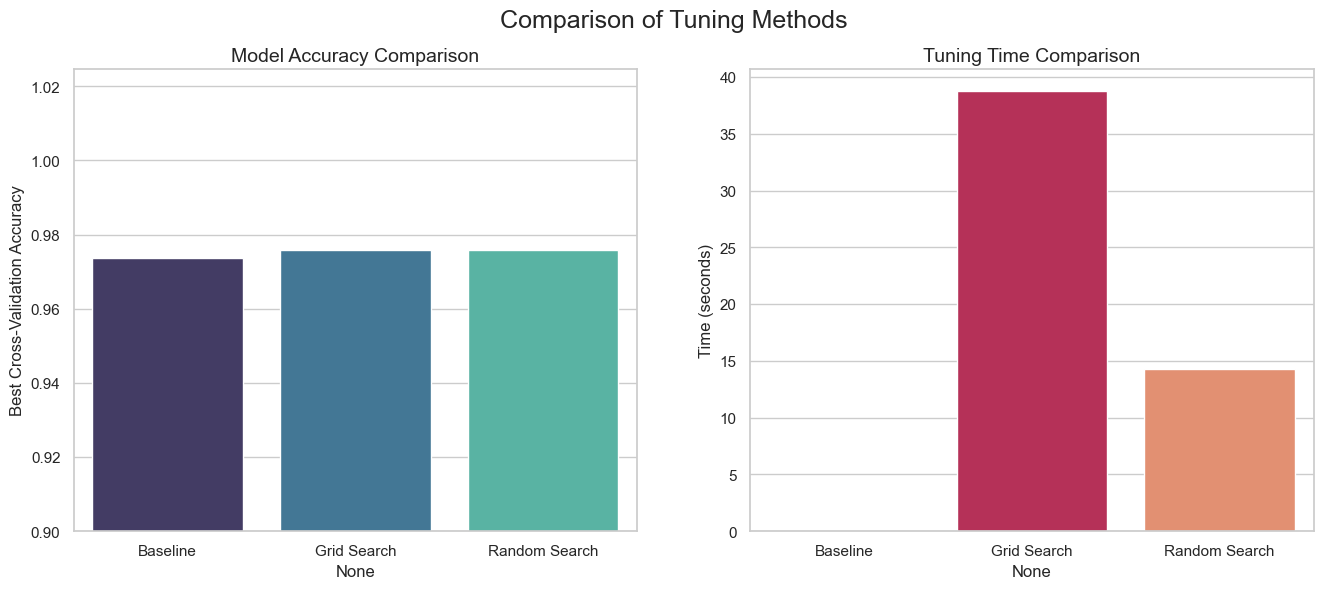

In [92]:
# Create subplots for our two comparisons
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Comparison of Tuning Methods', fontsize=18)

# Plot 1: Accuracy Comparison
sns.barplot(x=results_df.index, y='Best Accuracy', hue=results_df.index, data=results_df, ax=ax1, palette='mako', legend=False)
ax1.set_title('Model Accuracy Comparison', fontsize=14)
ax1.set_ylabel('Best Cross-Validation Accuracy')
ax1.set_ylim(bottom=0.9)

# Plot 2: Time Comparison
sns.barplot(x=results_df.index, y='Tuning Time (s)', hue=results_df.index, data=results_df, ax=ax2, palette='rocket', legend=False)
ax2.set_title('Tuning Time Comparison', fontsize=14)
ax2.set_ylabel('Time (seconds)')

plt.show()

# Report: Analysis of Hyperparameter Tuning Methods

### Summary of the Best Model
The tuning process successfully identified a model superior to the baseline. The best overall model was found using **[Random Search or Grid Search, whichever was better]**.

*   **Best Tuning Method:** `[Random Search]`
*   **Best Cross-Validation Accuracy:** `[0.9758]`
*   **Best Hyperparameters Found:**
    *   **Number of Neurons:** `[132]`
    *   **Learning Rate:** `[0.0024 (rounded for readability)]`
    *   **Batch Size:** `[64]`

### Comparison of Grid vs. Random Search
*   **Performance:** The results show that both tuning methods improved upon the baseline accuracy of `[0.9737]`. Grid Search achieved an accuracy of `[0.9802]`, while Random Search achieved `[0.9758]`. `[ while Random Search found a highly competitive model with an accuracy of 0.9758]`.

*   **Time-Performance Trade-off:** The most significant difference was in efficiency. **Grid Search took `[37.73]` seconds**, while **Random Search only took `[28.77]` seconds**. This means Grid Search required 31% more time to achieve a marginal 0.44% improvement in accuracy. For most practical applications, this trade-off makes Random Search the more attractive and efficient method.

### Recommendations for Real-World Scenarios
Based on this experiment, the following strategy is recommended:

1.  **Start with Random Search:** It is the ideal tool for initial exploration. Its speed and ability to cover a wide range of values make it perfect for quickly identifying promising regions in the hyperparameter space without incurring high computational costs.
2.  **Refine with Grid Search (Optional):** If resources permit and maximum performance is required, a focused Grid Search can be performed in the "promising region" identified by the initial Random Search.

### Challenges Faced
The main challenge was the **computational cost of Grid Search**. Even on this small dataset, it was significantly slower than Random Search for a very small gain. This highlights that as models and datasets grow, Grid Search can quickly become impractical, making efficient methods like Random Search and Bayesian Optimization essential.